In [4]:
import pandas as pd

# Ruta del archivo
file_path = '/content/velocidades_file.xlsx'

# Leer el archivo Excel en un DataFrame
try:
    df = pd.read_excel(file_path)
    print(f"Archivo '{file_path}' cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado.")
    df = None
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")
    df = None

# Mostrar los nombres de las columnas
if df is not None:
    print("\nNombres de las columnas:")
    for col in df.columns:
        print(f"- {col}")
else:
    print("No se pudo cargar el DataFrame, no se pueden mostrar los nombres de las columnas.")

# Buscar columnas con la palabra 'pozo' y mostrar nombres de pozos únicos
if df is not None:
    pozo_columns = [col for col in df.columns if 'pozo' in str(col).lower()]

    if pozo_columns:
        print("\nColumnas identificadas con la palabra 'pozo' en el encabezado:")
        for col in pozo_columns:
            print(f"- {col}")
            print(f"  Nombres de los pozos únicos en la columna '{col}':")
            # Asegurarse de manejar valores no-string si existen, y filtrar NaN
            unique_pozos = df[col].dropna().astype(str).unique()
            if len(unique_pozos) > 0:
                for pozo_name in unique_pozos:
                    print(f"    - {pozo_name}")
            else:
                print("    No se encontraron nombres de pozos en esta columna.")
    else:
        print("\nNo se encontraron columnas con la palabra 'pozo' en sus encabezados.")
else:
    print("No se pudo cargar el DataFrame, no se pueden buscar nombres de pozos.")

Archivo '/content/velocidades_file.xlsx' cargado exitosamente.

Nombres de las columnas:
- Bit_Position
- first_in
- first_out
- average_first
- nombre_comun_del_pozo
- avg_early_inout
- avg_early_smooth
- avg_all
- avg_all_smooth

Columnas identificadas con la palabra 'pozo' en el encabezado:
- nombre_comun_del_pozo
  Nombres de los pozos únicos en la columna 'nombre_comun_del_pozo':
    - PJP12
    - FRUp16


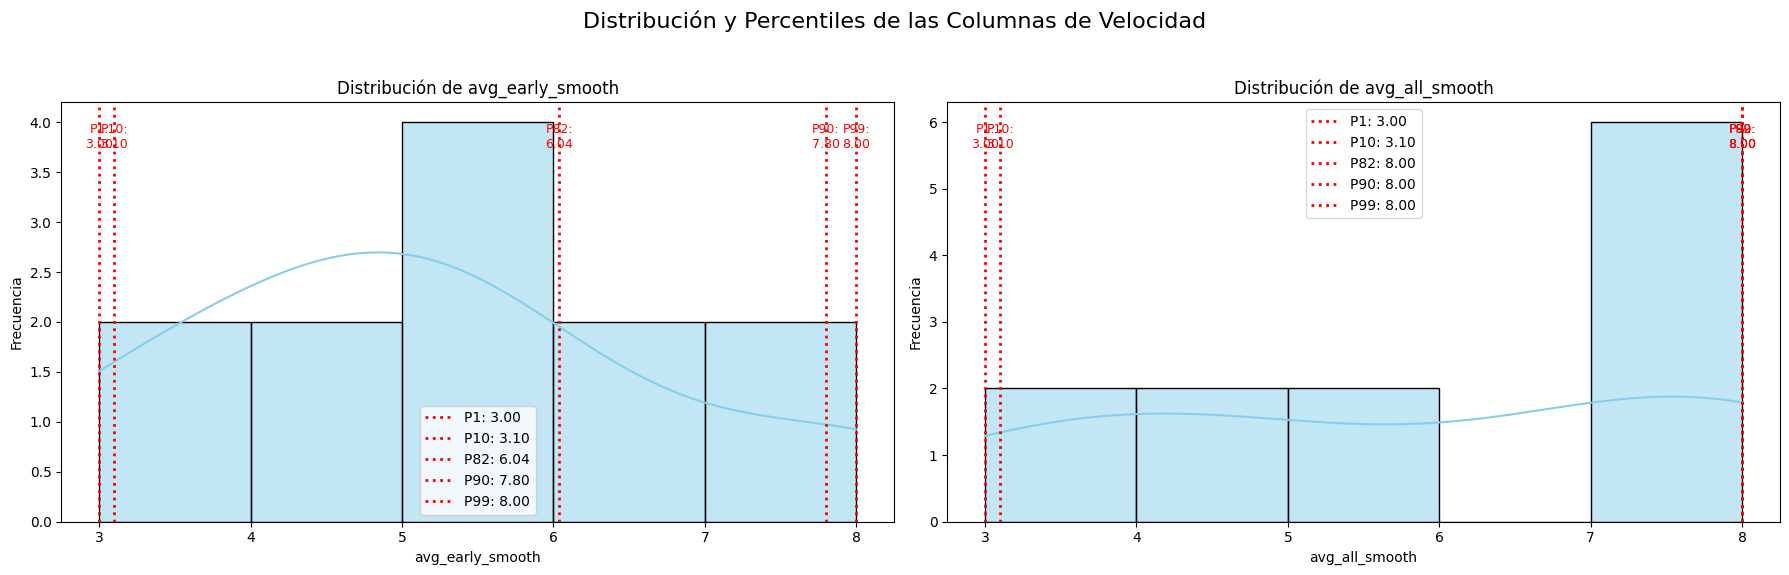

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the columns and percentiles to visualize
columns_to_plot = ['avg_early_smooth', 'avg_all_smooth']
percentiles_to_mark = [1, 10, 82, 90, 99]

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribución y Percentiles de las Columnas de Velocidad', fontsize=16)

for i, col_name in enumerate(columns_to_plot):
    if df is not None and col_name in df.columns:
        ax = axes[i]

        # Plot the distribution
        sns.histplot(df[col_name].dropna(), kde=True, ax=ax, color='skyblue', edgecolor='black')
        ax.set_title(f'Distribución de {col_name}')
        ax.set_xlabel(col_name)
        ax.set_ylabel('Frecuencia')

        # Calculate and mark percentiles
        for p in percentiles_to_mark:
            percentile_value = np.percentile(df[col_name].dropna(), p)
            ax.axvline(percentile_value, color='red', linestyle=':', linewidth=2,
                       label=f'P{p}: {percentile_value:.2f}')
            ax.text(percentile_value, ax.get_ylim()[1] * 0.95, f'P{p}:\n{percentile_value:.2f}',
                    color='red', ha='center', va='top', fontsize=9)
        ax.legend()
    else:
        ax = axes[i]
        ax.set_title(f'Columna {col_name} no disponible')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.text(0.5, 0.5, 'Datos no cargados o columna no encontrada',
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, color='gray', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [6]:
import numpy as np

# --- Configurable Percentile Variables for HQI_Inicial (avg_early_smooth) ---
# Calculate P1 and P90 for avg_early_smooth
p1_early_smooth = np.percentile(df['avg_early_smooth'].dropna(), 1)
p90_early_smooth = np.percentile(df['avg_early_smooth'].dropna(), 90)

P_min_inicial = p1_early_smooth  # P1 de avg_early_smooth
P_max_inicial = p90_early_smooth # P90 de avg_early_smooth

print(f"Valores configurables para HQI_Inicial (avg_early_smooth):\nP_min_inicial (P1): {P_min_inicial:.2f}\nP_max_inicial (P90): {P_max_inicial:.2f}")

# Calculate HQI_Inicial and clip values to be between 0 and 1
df['HQI_Inicial'] = (df['avg_early_smooth'] - P_min_inicial) / (P_max_inicial - P_min_inicial)
df['HQI_Inicial'] = np.clip(df['HQI_Inicial'], 0, 1)

Valores configurables para HQI_Inicial (avg_early_smooth):
P_min_inicial (P1): 3.00
P_max_inicial (P90): 7.80


In [7]:
# --- Configurable Percentile Variables for HQI_final (avg_all_smooth) ---
# Calculate P1 and P82 for avg_all_smooth
p1_all_smooth = np.percentile(df['avg_all_smooth'].dropna(), 1)
p82_all_smooth = np.percentile(df['avg_all_smooth'].dropna(), 82)

P_min_final = p1_all_smooth   # P1 de avg_all_smooth
P_max_final = p82_all_smooth  # P82 de avg_all_smooth

print(f"\nValores configurables para HQI_final (avg_all_smooth):\nP_min_final (P1): {P_min_final:.2f}\nP_max_final (P82): {P_max_final:.2f}")

# Calculate HQI_final and clip values to be between 0 and 1
df['HQI_final'] = (df['avg_all_smooth'] - P_min_final) / (P_max_final - P_min_final)
df['HQI_final'] = np.clip(df['HQI_final'], 0, 1)


Valores configurables para HQI_final (avg_all_smooth):
P_min_final (P1): 3.00
P_max_final (P82): 8.00


Aquí tienes las primeras filas del DataFrame con las nuevas columnas `HQI_Inicial` y `HQI_final`:

In [8]:
display(df.head())

,Bit_Position,first_in,first_out,average_first,nombre_comun_del_pozo,avg_early_inout,avg_early_smooth,avg_all,avg_all_smooth,HQI_Inicial,HQI_final
0,1,3,6,8,PJP12,4,8,6,8,1.000000,1.0
1,10,5,9,4,PJP12,5,5,5,3,0.416667,0.0
2,20,9,3,6,PJP12,74,6,4,4,0.625000,0.2
3,30,2,4,4,PJP12,3,5,8,5,0.416667,0.4
4,40,5,6,3,PJP12,5,3,0,7,0.000000,0.8


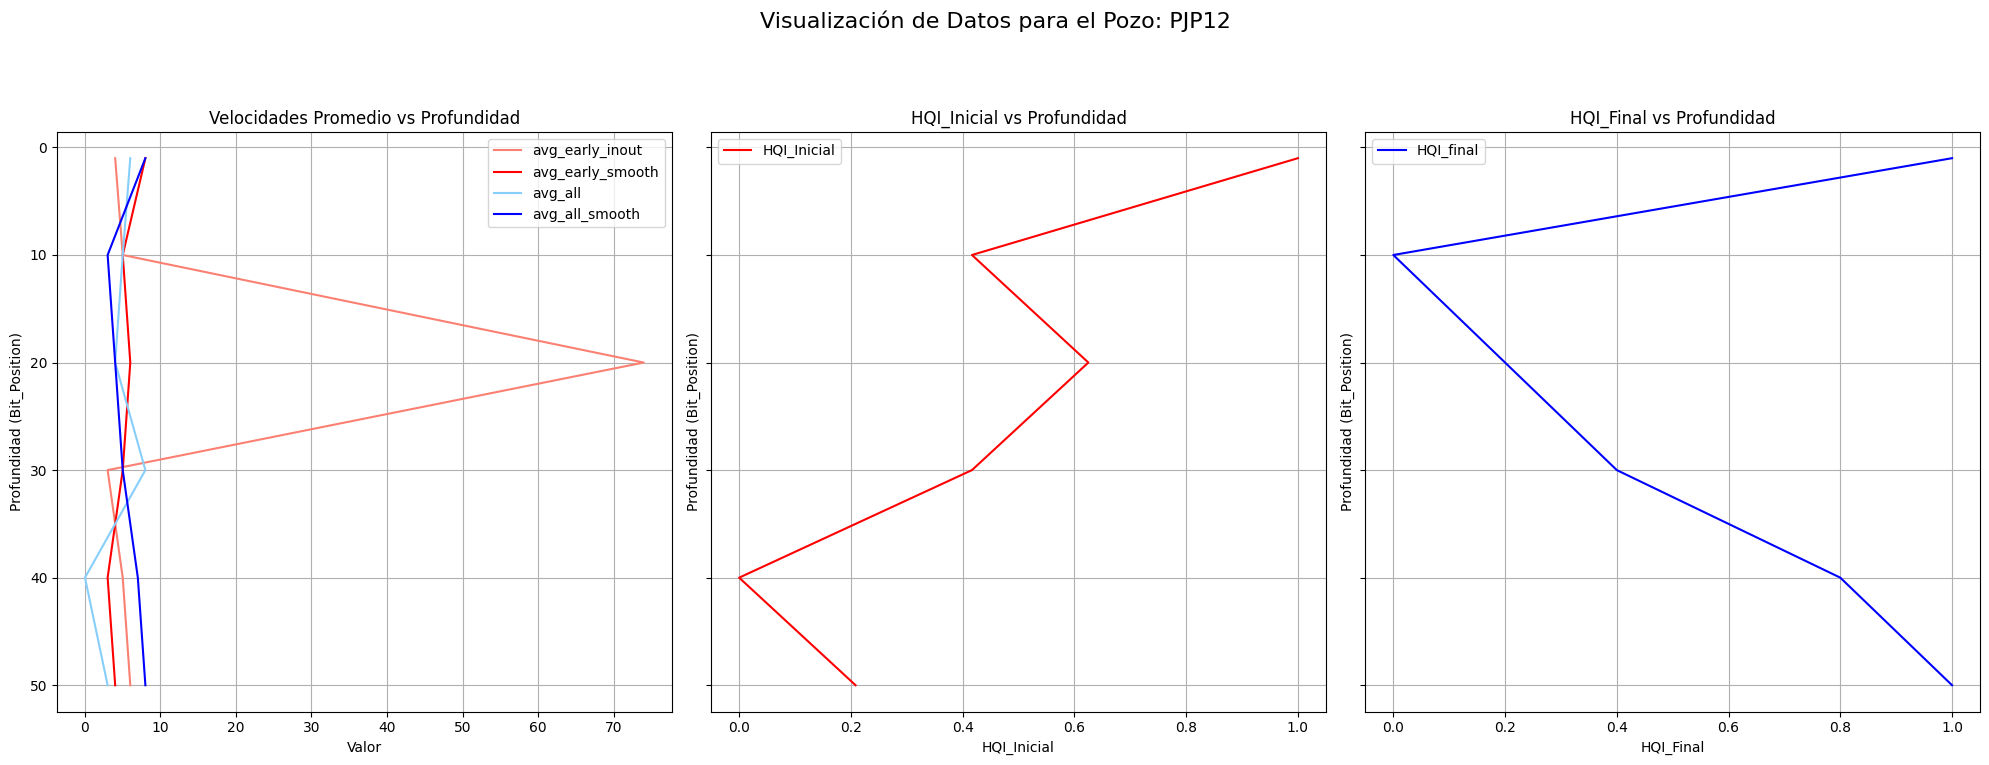

In [11]:
import matplotlib.pyplot as plt

# --- Configura el nombre del pozo a graficar aquí ---
pozo_a_graficar = 'PJP12' # Puedes cambiar 'PJP12' por 'FRUp16' o cualquier otro pozo

# Filtra el DataFrame para el pozo seleccionado
df_pozo = df[df['nombre_comun_del_pozo'] == pozo_a_graficar]

if not df_pozo.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True) # Aumentar la altura a 8
    fig.suptitle(f'Visualización de Datos para el Pozo: {pozo_a_graficar}', fontsize=16)

    # Primer Subplot: Columnas 'avg' vs Bit_Position
    ax1 = axes[0]
    ax1.plot(df_pozo['avg_early_inout'], df_pozo['Bit_Position'], color='salmon', label='avg_early_inout')
    ax1.plot(df_pozo['avg_early_smooth'], df_pozo['Bit_Position'], color='red', label='avg_early_smooth')
    ax1.plot(df_pozo['avg_all'], df_pozo['Bit_Position'], color='lightskyblue', label='avg_all')
    ax1.plot(df_pozo['avg_all_smooth'], df_pozo['Bit_Position'], color='blue', label='avg_all_smooth')
    ax1.set_title('Velocidades Promedio vs Profundidad')
    ax1.set_xlabel('Valor')
    ax1.set_ylabel('Profundidad (Bit_Position)')
    ax1.legend()
    ax1.grid(True)
    ax1.invert_yaxis() # Invertir el eje Y para la profundidad

    # Segundo Subplot: HQI_Inicial vs Bit_Position
    ax2 = axes[1]
    ax2.plot(df_pozo['HQI_Inicial'], df_pozo['Bit_Position'], color='red', label='HQI_Inicial')
    ax2.set_title('HQI_Inicial vs Profundidad')
    ax2.set_xlabel('HQI_Inicial')
    ax2.set_ylabel('Profundidad (Bit_Position)')
    ax2.legend()
    ax2.grid(True)
    ax2.invert_yaxis()

    # Tercer Subplot: HQI_Final vs Bit_Position
    ax3 = axes[2]
    ax3.plot(df_pozo['HQI_final'], df_pozo['Bit_Position'], color='blue', label='HQI_final')
    ax3.set_title('HQI_Final vs Profundidad')
    ax3.set_xlabel('HQI_Final')
    ax3.set_ylabel('Profundidad (Bit_Position)')
    ax3.legend()
    ax3.grid(True)
    ax3.invert_yaxis()

    plt.tight_layout(rect=[0, 0.03, 1, 0.92]) # Ajustar layout y espacio para el título general
    plt.show()
else:
    print(f"No se encontraron datos para el pozo '{pozo_a_graficar}'. Por favor, verifica el nombre.")